In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [95]:
data = pd.read_csv("/kaggle/creditcardcsvpresent.csv")


In [96]:
data.head()


,Merchant_id,Transaction date,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,3160040998,NaN,100.0,3000.0,N,5,Y,Y,0,0.0,0,Y
1,3160040998,NaN,100.0,4300.0,N,5,Y,Y,0,0.0,0,Y
2,3160041896,NaN,185.5,4823.0,Y,5,N,N,0,0.0,0,Y
3,3160141996,NaN,185.5,5008.5,Y,8,N,N,0,0.0,0,Y
4,3160241992,NaN,500.0,26000.0,N,0,Y,Y,800,677.2,6,Y


In [97]:
df = data.copy()

In [98]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Merchant_id                     3075 non-null   int64  
 1   Transaction date                0 non-null      float64
 2   Average Amount/transaction/day  3075 non-null   float64
 3   Transaction_amount              3075 non-null   float64
 4   Is declined                     3075 non-null   object 
 5   Total Number of declines/day    3075 non-null   int64  
 6   isForeignTransaction            3075 non-null   object 
 7   isHighRiskCountry               3075 non-null   object 
 8   Daily_chargeback_avg_amt        3075 non-null   int64  
 9   6_month_avg_chbk_amt            3075 non-null   float64
 10  6-month_chbk_freq               3075 non-null   int64  
 11  isFradulent                     3075 non-null   object 
dtypes: float64(4), int64(4), object(4)

In [99]:
df.columns

Index(['Merchant_id', 'Transaction date', 'Average Amount/transaction/day',
       'Transaction_amount', 'Is declined', 'Total Number of declines/day',
       'isForeignTransaction', 'isHighRiskCountry', 'Daily_chargeback_avg_amt',
       '6_month_avg_chbk_amt', '6-month_chbk_freq', 'isFradulent'],
      dtype='object')

In [100]:
df.shape

(3075, 12)

In [101]:
df = df.drop('Transaction date', axis=1)

In [102]:
df =df.drop('Merchant_id', axis = 1)

In [103]:
df.describe()

,Average Amount/transaction/day,Transaction_amount,Total Number of declines/day,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq
count,3075.000000,3075.000000,3075.000000,3075.000000,3075.000000,3075.000000
mean,515.026556,9876.399210,0.957398,55.737561,40.022407,0.391870
std,291.906978,10135.331016,2.192391,206.634779,155.968840,1.548479
min,4.011527,0.000000,0.000000,0.000000,0.000000,0.000000
25%,269.788047,2408.781147,0.000000,0.000000,0.000000,0.000000
50%,502.549575,6698.891856,0.000000,0.000000,0.000000,0.000000
75%,765.272803,14422.568935,0.000000,0.000000,0.000000,0.000000
max,2000.000000,108000.000000,20.000000,998.000000,998.000000,9.000000


In [104]:
df.isnull().sum()

,0
Average Amount/transaction/day,0
Transaction_amount,0
Is declined,0
Total Number of declines/day,0
isForeignTransaction,0
isHighRiskCountry,0
Daily_chargeback_avg_amt,0
6_month_avg_chbk_amt,0
6-month_chbk_freq,0
isFradulent,0


In [105]:
df.head()

,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,100.0,3000.0,N,5,Y,Y,0,0.0,0,Y
1,100.0,4300.0,N,5,Y,Y,0,0.0,0,Y
2,185.5,4823.0,Y,5,N,N,0,0.0,0,Y
3,185.5,5008.5,Y,8,N,N,0,0.0,0,Y
4,500.0,26000.0,N,0,Y,Y,800,677.2,6,Y


In [106]:
for col in df.select_dtypes("object").columns:

  if col in ['Is declined', 'isForeignTransaction', 'isHighRiskCountry', 'isFradulent']:
    df[col] = df[col].replace({'Y': 1, 'N': 0})




/tmp/ipykernel_1623/3392394671.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Y': 1, 'N': 0})


                                Average Amount/transaction/day  \
Average Amount/transaction/day                        1.000000   
Transaction_amount                                    0.587111   
Is declined                                           0.081184   
Total Number of declines/day                         -0.009682   
isForeignTransaction                                  0.047316   
isHighRiskCountry                                     0.014604   
Daily_chargeback_avg_amt                              0.060429   
6_month_avg_chbk_amt                                  0.060284   
6-month_chbk_freq                                     0.071849   
isFradulent                                           0.023504   

                                Transaction_amount  Is declined  \
Average Amount/transaction/day            0.587111     0.081184   
Transaction_amount                        1.000000     0.197009   
Is declined                               0.197009     1.000000   
Total

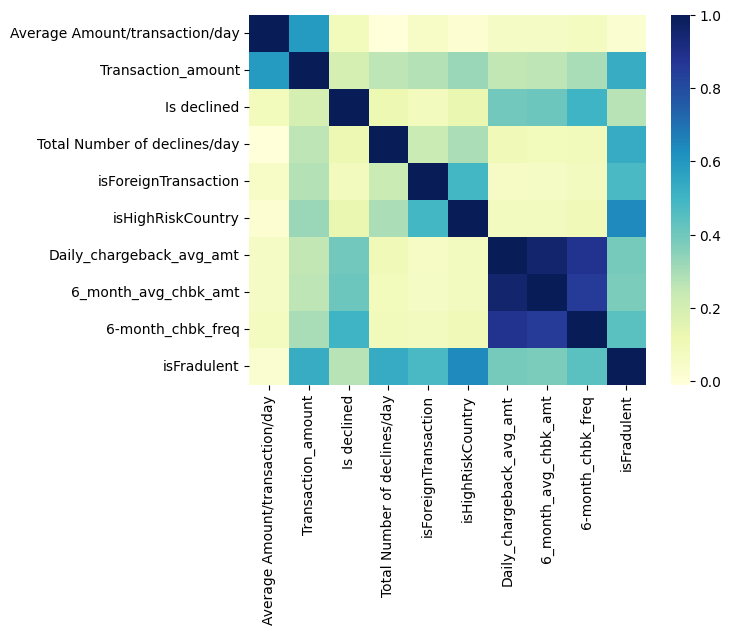

In [107]:
df
correlation_matrix = df.corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, cmap ='YlGnBu' )
plt.show()

# Logistic Regression

In [108]:
#logistic regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score as f1_score_func, roc_auc_score, confusion_matrix, recall_score, precision_score

In [109]:
df.head()

,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,100.0,3000.0,0,5,1,1,0,0.0,0,1
1,100.0,4300.0,0,5,1,1,0,0.0,0,1
2,185.5,4823.0,1,5,0,0,0,0.0,0,1
3,185.5,5008.5,1,8,0,0,0,0.0,0,1
4,500.0,26000.0,0,0,1,1,800,677.2,6,1


In [110]:
X = df.drop(['isFradulent'], axis=1)
y = df['isFradulent']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter =1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,

Accuracy: 0.99
Precision: 0.98
Recall: 0.96
F1 Score: 0.97

Confusion Matrix:
[[523   2]
 [  4  86]]


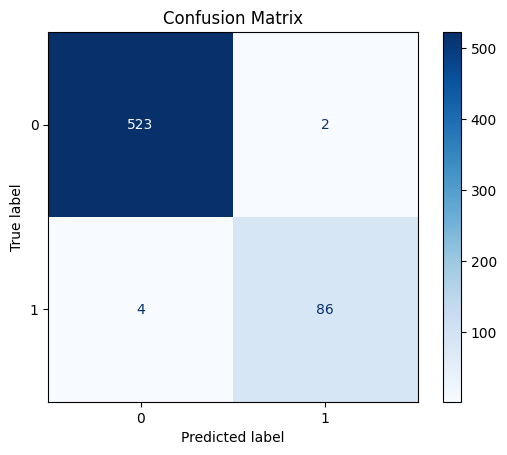

In [111]:
#metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
precision = precision_score(y_test, y_pred)
recall =recall_score(y_test,y_pred)
f1_score_val = f1_score_func(y_test,y_pred) # Now calling the renamed function

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1_score_val:.2f}')
print('\nConfusion Matrix:')
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues) # Use a blue color map for better visualization
plt.title('Confusion Matrix')
plt.show()

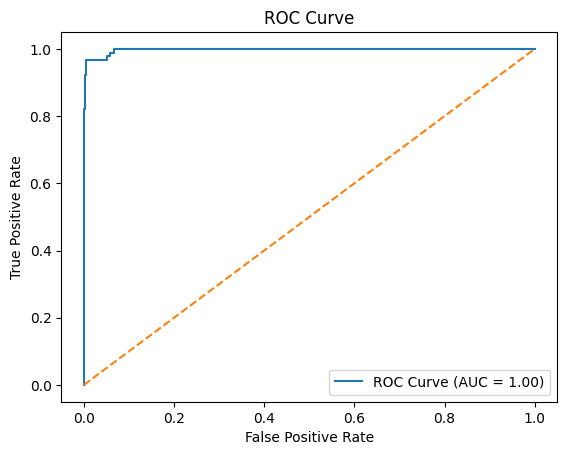

In [112]:
from sklearn.metrics import roc_curve
y_prob = model.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(false_positive_rate, true_positive_rate, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [113]:
#random forests and svm are good models as well, random forests are able to create multiple decision trees

# RandomForestClassifier

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score as accuracy_score_func, classification_report

rfdf = data.copy()
# Ensure isFradulent is numeric (0/1) for rfdf as well
for col in rfdf.select_dtypes("object").columns:
    if col in ['Is declined', 'isForeignTransaction', 'isHighRiskCountry', 'isFradulent']:
        rfdf[col] = rfdf[col].replace({'Y': 1, 'N': 0})

/tmp/ipykernel_1623/1439081445.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rfdf[col] = rfdf[col].replace({'Y': 1, 'N': 0})


Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       525
           1       0.99      0.94      0.97        90

    accuracy                           0.99       615
   macro avg       0.99      0.97      0.98       615
weighted avg       0.99      0.99      0.99       615



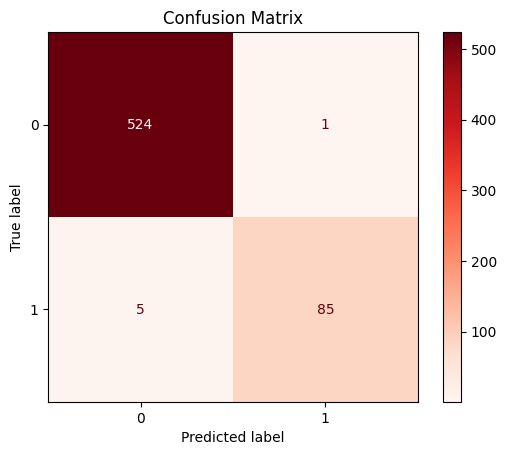

In [115]:
x_rf = rfdf.drop(['isFradulent'], axis=1)
y_rf = rfdf['isFradulent']
# Use x_rf and y_rf for splitting for Random Forest
X_trainrf, X_testrf, y_trainrf, y_testrf = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_trainrf,y_trainrf)
y_predrf = rf_classifier.predict(X_testrf)
accuracyrf = accuracy_score_func(y_testrf,y_predrf)
classification_reprf = classification_report(y_testrf, y_predrf)

print(f"Accuracy: {accuracyrf:.2f}")
print("\nClassification Report:\n", classification_reprf)
conf_matrix = confusion_matrix(y_testrf,y_predrf)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Reds) # Use a red color map for better visualization
plt.title('Confusion Matrix')
plt.show()

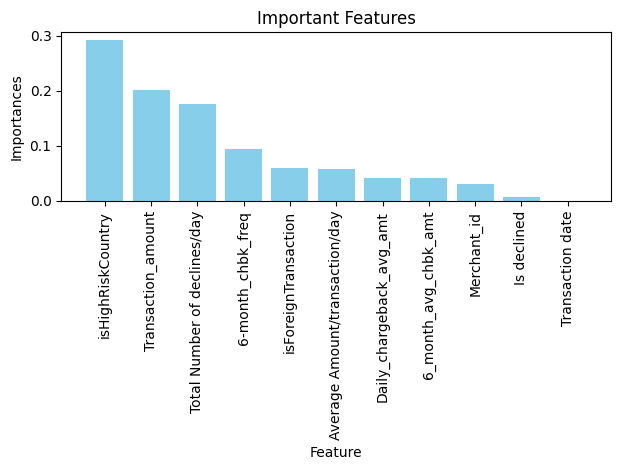

In [116]:
important = rf_classifier.feature_importances_
indices = np.argsort(important)[::-1]
plt.figure()
plt.title("Important Features")
plt.bar(range(len(important)), important[indices], color = "skyblue")
plt.xticks(range(len(important)), x_rf.columns[indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importances")
plt.tight_layout()
plt.show()

In [117]:
#The dataset is likely unbalanced because the data heavily favors one outcome over the other. Balanced bagging is useful in making sure that the minority outcome is not ignored.
from imblearn.ensemble import BalancedBaggingClassifier




In [118]:
X_trainrf, X_testrf, y_trainrf, y_testrf = train_test_split(X,y,test_size=0.2, random_state=42)
balanced_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
balanced_bagging = BalancedBaggingClassifier(
    estimator=balanced_classifier,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)
balanced_bagging.fit(X_trainrf, y_trainrf)
y_pred = balanced_bagging.predict(X_testrf)
print("Accuracy:", accuracy_score(y_testrf, y_pred))
print("Classification Report:\n", classification_report(y_testrf, y_pred))

Accuracy: 0.9723577235772358
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       512
           1       0.86      0.99      0.92       103

    accuracy                           0.97       615
   macro avg       0.93      0.98      0.95       615
weighted avg       0.98      0.97      0.97       615



Class distribution before SMOTE: Counter({0: 2115, 1: 345})
Class distribution after SMOTE: Counter({1: 2115, 0: 2115})
Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       512
           1       0.83      0.99      0.90       103

    accuracy                           0.96       615
   macro avg       0.91      0.97      0.94       615
weighted avg       0.97      0.96      0.97       615



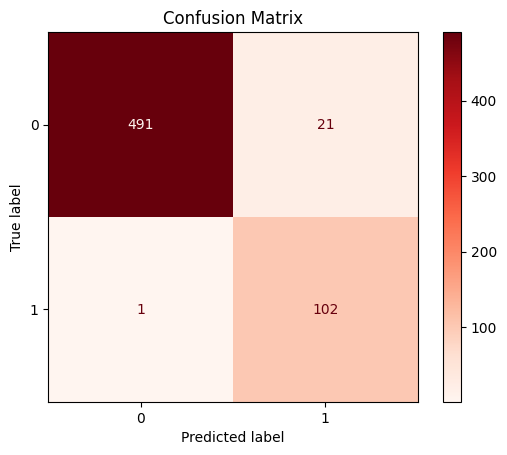

In [135]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:", Counter(y_train_resampled))

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_resampled,y_train_resampled)
y_pred_smote = rf_smote.predict(X_test_smote)
accuracy_smote = accuracy_score_func(y_test_smote,y_pred_smote)
classification_rep_smote = classification_report(y_test_smote, y_pred_smote)

print(f"Accuracy: {accuracy_smote:.2f}")
print("\nClassification Report:\n", classification_rep_smote)
conf_matrix_smote = confusion_matrix(y_test_smote,y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_smote)
disp.plot(cmap=plt.cm.Reds) # Use a red color map for better visualization
plt.title('Confusion Matrix')
plt.show()

# XGBboost

In [120]:
#XGBoost
import xgboost as xgb
from xgboost import XGBClassifier


In [128]:
X_xgb, y_xgb = df.drop(['isFradulent'], axis=1), df['isFradulent']
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb)
scaler_xgb = StandardScaler()
X_train_xgb_scaled = scaler_xgb.fit_transform(X_train_xgb)
X_test_xgb_scaled = scaler_xgb.transform(X_test_xgb)
param = {
    'max_depth': 4,
    'learning_rate' : 0.05,
    'n_estimators':250,
    'alpha': 10
}
model = XGBClassifier(**param)

model.fit(X_train_xgb_scaled, y_train_xgb)
y_pred = model.predict(X_test_xgb_scaled)

Accuracy: 0.99
Precision: 0.99
Recall: 0.92
F1 Score: 0.95

Confusion Matrix:
[[524   1]
 [  7  83]]


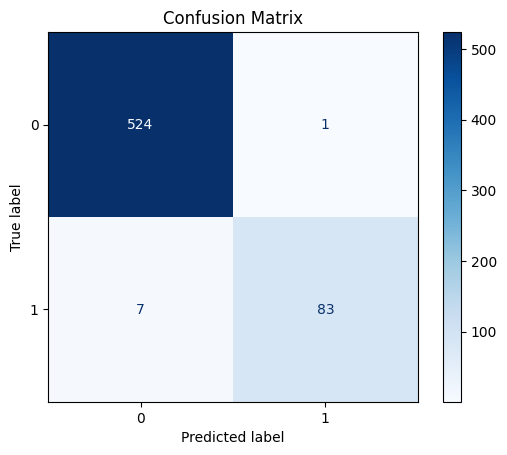

In [129]:
accuracy = accuracy_score(y_test_xgb,y_pred) # Use y_test_xgb
cm = confusion_matrix(y_test_xgb,y_pred) # Use y_test_xgb
precision = precision_score(y_test_xgb, y_pred) # Use y_test_xgb
recall =recall_score(y_test_xgb,y_pred) # Use y_test_xgb
f1_score_val = f1_score_func(y_test_xgb,y_pred) # Now calling the renamed function

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1_score_val:.2f}')
print('\nConfusion Matrix:')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues) # Use a blue color map for better visualization
plt.title('Confusion Matrix')
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

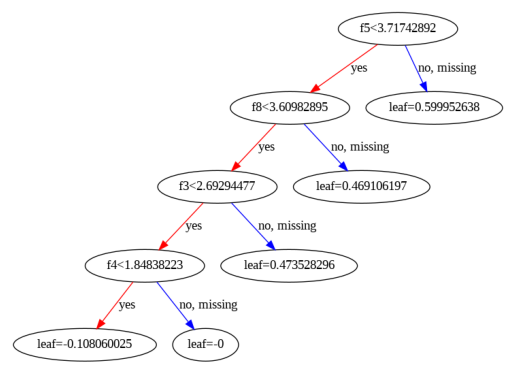

In [125]:
#plot tree
plt.figure(figsize = (20,10))
xgb.plot_tree(model,num_trees=0)
plt.show()



# SVC

In [ ]:
#SVC
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Re-split and scale X and y for SVC
X_svc, y_svc = df.drop(['isFradulent'], axis=1), df['isFradulent']
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(X_svc, y_svc, test_size=0.2, random_state=42, stratify=y_svc)

scaler_svc = StandardScaler()
X_train_svc_scaled = scaler_svc.fit_transform(X_train_svc)
X_test_svc_scaled = scaler_svc.transform(X_test_svc)

svc = SVC(kernel = 'rbf', C=1, probability = True, random_state = 42)
svc.fit(X_train_svc_scaled, y_train_svc) # y_train_svc should already be numeric (0/1)
print("SVC model trained successfully.")

In [ ]:
y_pred_svc = svc.predict(X_test_svc_scaled) # Use scaled test data
# y_test_svc should already be numeric (0/1) from initial df conversion

accuracy = accuracy_score(y_test_svc, y_pred_svc)
cm = confusion_matrix(y_test_svc, y_pred_svc)
precision = precision_score(y_test_svc, y_pred_svc)
recall = recall_score(y_test_svc, y_pred_svc)
f1_score_val = f1_score_func(y_test_svc, y_pred_svc)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1_score_val:.2f}')
print('\nConfusion Matrix:')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('SVC Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_prob_svc = svc.predict_proba(X_test_svc_scaled)[:, 1] # Use scaled test data
fpr_svc, tpr_svc,_ = roc_curve(y_test_svc, y_prob_svc) # Use y_test_svc
roc_auc_svc = auc(fpr_svc, tpr_svc)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_svc:.2f})')
plt.plot([0, 1], [0, 1], linestyle="--", color='k', label='Random Classifier') # Corrected k-- to full line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVC ROC Curve')
plt.legend(loc='lower right')
precision_svc_curve, recall_svc_curve, _ = precision_recall_curve(y_test_svc, y_prob_svc) # Use y_test_svc
pr_auc_svc = average_precision_score(y_test_svc, y_prob_svc) # Use y_test_svc
plt.subplot(1, 2, 2)
plt.plot(recall_svc_curve, precision_svc_curve, label=f'SVC (AP = {pr_auc_svc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVC Precision-Recall Curve')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [130]:
param = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 0.2, 0.5, 1, 2, 100, 200]

}
svm_grid = GridSearchCV(SVC(probability = True, random_state =42), param_grid = param, cv =3, n_jobs=-1, verbose = 2)

In [132]:
svm_grid.fit(X_train_svc_scaled,y_train_svc)
print("Best parameters found by GridSearchCV:", svm_grid.best_params_)

Fitting 3 folds for each of 28 candidates, totalling 84 fits
Best parameters found by GridSearchCV: {'C': 200, 'kernel': 'linear'}


In [138]:
from prettytable import PrettyTable
comp_chart = PrettyTable(["Statistical Model", "Accuracy", "Precision", "Recall", "F1 Score" ])

comp_chart.add_row(["Logistic Regression", "0.99", "0.98", "0.96", "0.97"])
comp_chart.add_row(["Random Forest", "0.99", "0.99", "0.94", "0.97"])
comp_chart.add_row(["Balanced Bagging + Random Forest", "0.97", "0.86", "0.99", "0.92"])
comp_chart.add_row(["SMOTE + Random Forest", "0.96", "0.83", "0.99", "0.90"])
comp_chart.add_row(["XGBoost", "0.99", "0.99", "0.92", "0.95"])
comp_chart.add_row(["SVC", "0.99", "0.98", "0.96", "0.97"])

print(comp_chart)

+----------------------------------+----------+-----------+--------+----------+
|        Statistical Model         | Accuracy | Precision | Recall | F1 Score |
+----------------------------------+----------+-----------+--------+----------+
|       Logistic Regression        |   0.99   |    0.98   |  0.96  |   0.97   |
|          Random Forest           |   0.99   |    0.99   |  0.94  |   0.97   |
| Balanced Bagging + Random Forest |   0.97   |    0.86   |  0.99  |   0.92   |
|      SMOTE + Random Forest       |   0.96   |    0.83   |  0.99  |   0.90   |
|             XGBoost              |   0.99   |    0.99   |  0.92  |   0.95   |
|               SVC                |   0.99   |    0.98   |  0.96  |   0.97   |
+----------------------------------+----------+-----------+--------+----------+
